In [1]:
import tensorflow as tf
import pathlib

dataset_url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

#Como las clases están dentro de una subcarpeta 'flower_photos'
data_dir = data_dir / 'flower_photos'

print(f"Directorio de imágenes: {data_dir}")
print(f"Carpetas de clases: {[f.name for f in data_dir.iterdir() if f.is_dir()]}")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Directorio de imágenes: /root/.keras/datasets/flower_photos/flower_photos
Carpetas de clases: ['roses', 'tulips', 'daisy', 'sunflowers', 'dandelion']


In [2]:
# Contar imágenes por clase
import os

print("Cantidad de imágenes por clase:")
print("-" * 30)

for clase in ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']:
    clase_path = data_dir / clase
    if clase_path.exists():
        num_imagenes = len(list(clase_path.glob('*.jpg')))
        print(f"{clase}: {num_imagenes} imágenes")
    else:
        print(f"{clase}: Carpeta no encontrada")

print("-" * 30)
total = sum(len(list((data_dir / clase).glob('*.jpg'))) for clase in ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'] if (data_dir / clase).exists())
print(f"Total: {total} imágenes")

Cantidad de imágenes por clase:
------------------------------
daisy: 633 imágenes
dandelion: 898 imágenes
roses: 641 imágenes
sunflowers: 699 imágenes
tulips: 799 imágenes
------------------------------
Total: 3670 imágenes


In [3]:
#Se crea el set de entrenamiento (80%)
train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(180, 180),
    batch_size=32
)

#Se crea el set de validaciones (20%)
validation = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(180, 180),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [4]:
# Calcular pesos para balancear las clases
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Obtener todas las etiquetas del conjunto de entrenamiento
y_train = []
for images, labels in train:
    y_train.extend(labels.numpy())
y_train = np.array(y_train)

# Calcular pesos balanceados
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Mostrar los pesos por clase
print("Pesos por clase (mayor peso = clase con menos imágenes):")
for i, (name, weight) in enumerate(zip(train.class_names, class_weights)):
    print(f"  {name}: {weight:.2f}")

# También mostrar distribución actual
print("\nDistribución actual en entrenamiento:")
class_counts = {}
for label in y_train:
    class_name = train.class_names[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

total = sum(class_counts.values())
for name, count in class_counts.items():
    print(f"  {name}: {count} imágenes ({count/total:.1%})")

Pesos por clase (mayor peso = clase con menos imágenes):
  daisy: 1.12
  dandelion: 0.83
  roses: 1.12
  sunflowers: 1.04
  tulips: 0.95

Distribución actual en entrenamiento:
  daisy: 526 imágenes (17.9%)
  tulips: 617 imágenes (21.0%)
  dandelion: 707 imágenes (24.1%)
  sunflowers: 564 imágenes (19.2%)
  roses: 522 imágenes (17.8%)


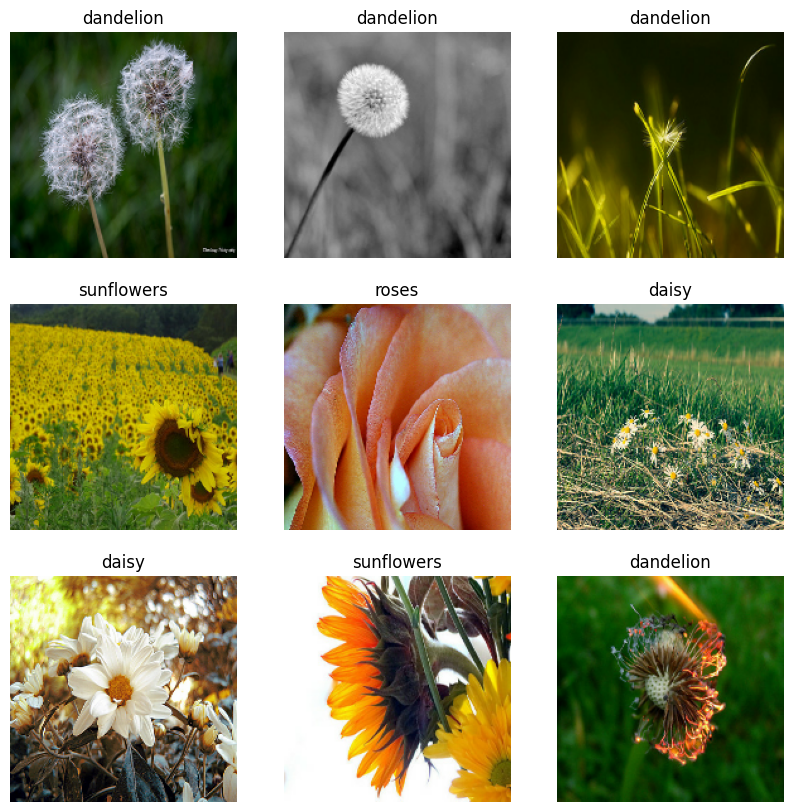

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

clases = 5

model = models.Sequential([
    # Capa Input explícita
    layers.Input(shape=(180, 180, 3)),
    
    # Preprocesamiento: reescalado de 0-255 a 0-1
    layers.Rescaling(1./255),
    
    # Data augmentation para más variedad
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    
    # Bloque 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Bloque 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Bloque 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
    # Clasificador
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(clases, activation='softmax')
])

In [7]:
#Compilamos el modelo

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 8,035,525 (30.65 MB)

 Trainable params: 8,034,629 (30.65 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Agregamos EarlyStopping para evitar sobreajuste en el modelo
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True,
    verbose = 1
)

# Reduce learning rate cuando se estanque
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
  train,
  validation_data = validation,
  epochs = 50,
  class_weight = class_weight_dict,
  callbacks = [early_stop, reduce_lr]
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.2752 - loss: 2.6944 - val_accuracy: 0.2616 - val_loss: 3.6422 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.3542 - loss: 2.3957 - val_accuracy: 0.2602 - val_loss: 3.2908 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.4067 - loss: 2.2281 - val_accuracy: 0.3188 - val_loss: 2.2529 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.4571 - loss: 2.0241 - val_accuracy: 0.4278 - val_loss: 2.1225 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.4465 - loss: 2.0139 - val_accuracy: 0.5027 - val_loss: 1.8568 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.4745 - loss: 1.8954 - val_accuracy: 0.5218 - val_loss: 1.8357 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.4976 - loss: 1.

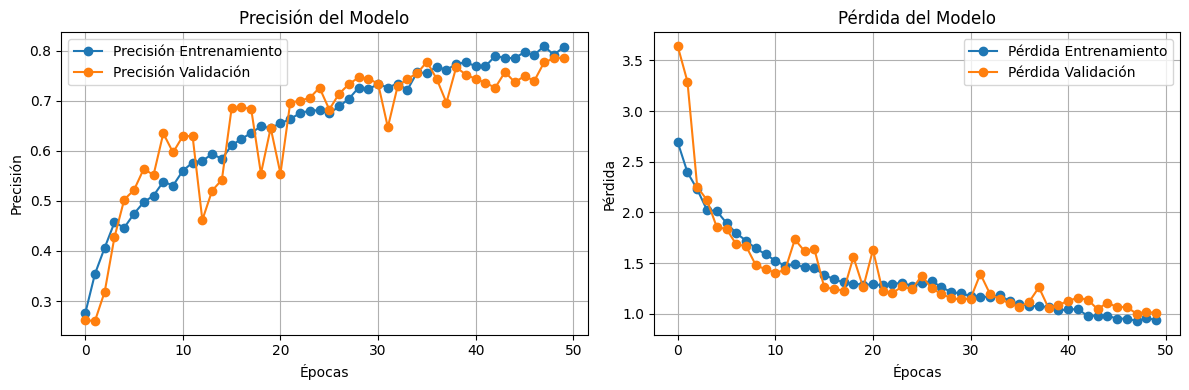

Mejor precisión de validación: 0.7861
Épocas entrenadas: 50


In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Precisión Validación', marker='o')
plt.legend()
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento', marker='o')
plt.plot(epochs_range, val_loss, label='Pérdida Validación', marker='o')
plt.legend()
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Mejor precisión de validación: {max(val_acc):.4f}")
print(f"Épocas entrenadas: {len(acc)}")

In [10]:
#Extraer los nombres de las clases
nombreClases = train.class_names
print(f"Las clases presentes son: {nombreClases}")

Las clases presentes son: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [11]:
# Evaluar el modelo en validación
val_loss, val_accuracy = model.evaluate(validation, verbose=0)
print(f"Precisión en validación: {val_accuracy:.4f}")
print(f"Pérdida en validación: {val_loss:.4f}")

# Reporte detallado por clase
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in validation:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("\n--- REPORTE POR CLASE ---")
print(classification_report(y_true, y_pred, target_names=train.class_names))

# Comparar con los pesos que usamos
print("\n--- COMPARACIÓN DE PESOS ---")
print("Clase / Peso asignado / Precisión")
for i, name in enumerate(train.class_names):
    precision = classification_report(y_true, y_pred, target_names=train.class_names, output_dict=True)[name]['precision']
    print(f"{name}: {class_weights[i]:.2f} / {precision:.2f}")

Precisión en validación: 0.7766
Pérdida en validación: 1.0008

--- REPORTE POR CLASE ---
              precision    recall  f1-score   support

       daisy       0.79      0.79      0.79       107
   dandelion       0.84      0.76      0.80       191
       roses       0.71      0.73      0.72       119
  sunflowers       0.77      0.87      0.82       135
      tulips       0.75      0.75      0.75       182

    accuracy                           0.78       734
   macro avg       0.77      0.78      0.78       734
weighted avg       0.78      0.78      0.78       734


--- COMPARACIÓN DE PESOS ---
Clase / Peso asignado / Precisión
daisy: 1.12 / 0.79
dandelion: 0.83 / 0.84
roses: 1.12 / 0.71
sunflowers: 1.04 / 0.77
tulips: 0.95 / 0.75


In [13]:
from google.colab import drive
drive.mount('/content/drive')

# Guardar el modelo en Drive
model.save('/content/drive/MyDrive/modelo_flores.keras')
print("Modelo guardado en: /content/drive/MyDrive/modelo_flores.keras")

Mounted at /content/drive
Modelo guardado en: /content/drive/MyDrive/modelo_flores.keras


In [14]:
import json

# Guardar los nombres de las clases
with open('/content/drive/MyDrive/class_names.json', 'w') as f:
    json.dump(train.class_names, f)
print("Nombres de clases guardados en: /content/drive/MyDrive/class_names.json")

# Verificar que se guardaron correctamente
print(f"Clases: {train.class_names}")

Nombres de clases guardados en: /content/drive/MyDrive/class_names.json
Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
